# Pseudo-3D: quadrado “de perfil” (projeção perspétiva)

Este notebook parte de uma imagem **plana** (`quadrado.png`) e aplica uma **transformação geométrica** que simula o mesmo desenho visto **depois de girar o plano da figura em torno do eixo vertical** (como se o quadrado tivesse se **virado para o lado** em relação à câmera). A profundidade aparece pela **perspectiva** (lado mais próximo ocupa mais largura na imagem que o lado mais afastado), não por um ciclo de “dança” no tempo.

**Preservação de cor:** cada pixel de saída obtém o RGB **apenas por amostragem** da textura original (interpolação bilinear). Não há recolorização intencional — só mudança de **geometria projetiva**.

## 1. Conceitos

- **Plano texturizado:** a imagem é tratada como uma **textura** colada num retângulo no espaço 3D (plano \(z=0\), centrado na origem).
- **Rotação em torno de \(Y\):** o plano gira de um ângulo \(\theta\) (eixo vertical passando pelo centro). O lado do quadrado que se aproxima da câmera **alarga** na projeção; o que se afasta **encolhe** — típico de perspectiva, como ver uma folha de frente vs. de lado.
- **Projeção perspétiva:** a câmera está em \((0,0,d)\) com \(d>0\); para cada pixel da **imagem de saída** traçamos o raio correspondente, achamos a interseção com o plano rotacionado e **voltamos** ao sistema antes da rotação para ler \((s,t)\) na textura.
- **Cores:** amostragem bilinear na textura; os três canais usam o **mesmo** par \((\text{linha}, \text{coluna})\) de origem.

**Observação:** isto não reconstrói o verso do objeto (continua sendo uma única textura 2D); o efeito é **geométrico**, análogo a “inclinar” o plano da foto no espaço.

In [14]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from scipy.ndimage import map_coordinates

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["image.interpolation"] = "nearest"

## 2. Entrada: `quadrado.png`

O arquivo deve estar na **mesma pasta** deste notebook (ou ajuste `CAMINHO_IMAGEM`). Se não existir, geramos um exemplo com um quadrado colorido só para você executar o fluxo completo.

Tamanho: 512 x 512


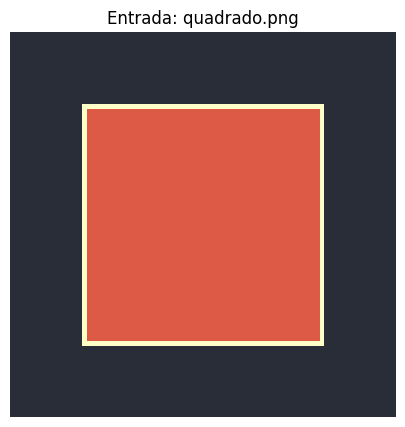

In [15]:
BASE = Path.cwd()
CAMINHO_IMAGEM = BASE / "quadrado.png"

if not CAMINHO_IMAGEM.is_file():
    w, h = 512, 512
    img_demo = Image.new("RGB", (w, h), (40, 45, 55))
    dr = ImageDraw.Draw(img_demo)
    margin = 96
    dr.rectangle(
        [margin, margin, w - margin, h - margin],
        fill=(220, 90, 70),
        outline=(255, 255, 200),
        width=6,
    )
    img_demo.save(CAMINHO_IMAGEM)
    print(f"Criado arquivo de demonstração: {CAMINHO_IMAGEM}")

im_pil = Image.open(CAMINHO_IMAGEM).convert("RGB")
im = np.asarray(im_pil, dtype=np.float32) / 255.0
H, W, _ = im.shape
print("Tamanho:", W, "x", H)

plt.imshow(im)
plt.title("Entrada: quadrado.png")
plt.axis("off")
plt.show()

## 3. Modelo 3D + projeção

A textura ocupa o retângulo \(x \in [-1,1]\), \(y \in [-1,1]\) no plano \(z=0\). A rotação \(\mathrm{R}_y(\theta)\) leva um ponto \((x,y,0)\) a \((x\cos\theta,\,y,\,-x\sin\theta)\). A câmera em \((0,0,d)\) olha na direção do plano; para cada pixel da imagem de saída calculamos o **raio** correspondente, a **interseção** com o plano rotacionado e a inversa \(\mathrm{R}_y(-\theta)\) para obter \((x,y)\) na textura e amostrar o RGB.

A saída desta seção usa **`ANGULO_GRAUS = 13`** na célula seguinte; altere esse valor para mais ou menos “virada”.

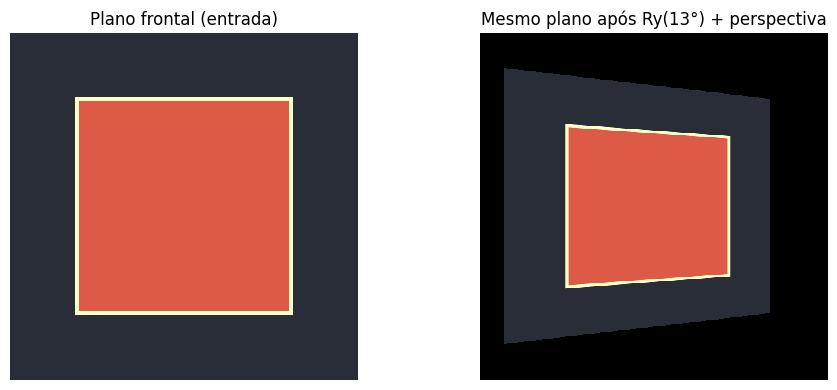

In [16]:
def perspectiva_plano_rotacao_y(
    rgb: np.ndarray,
    angulo_rad: float,
    dist_camera: float = 2.0,
    escala_campo: float = 0.72,
):
    """
    rgb: float32 [H,W,3] em [0,1].
    Simula ver o plano da textura após rotação Ry(angulo_rad) e projeção perspética.
    `escala_campo` < 1 estreita o feixe de raios (equivalente a um zoom) para o
    trapézio projetado ocupar melhor o quadro de saída.
    Retorna (imagem_saida, mascara_valida) com mesma resolução.
    """
    h, w, _ = rgb.shape
    jj, ii = np.mgrid[0:h, 0:w].astype(np.float64)
    sx = ((ii / max(w - 1, 1)) * 2.0 - 1.0) * escala_campo
    sy = (-((jj / max(h - 1, 1)) * 2.0 - 1.0)) * escala_campo

    c, s = float(np.cos(angulo_rad)), float(np.sin(angulo_rad))
    d = float(dist_camera)
    vx, vy, vz = sx, sy, -1.0
    denom = s * vx + c * vz
    eps = 1e-9
    valid = np.abs(denom) > eps
    t = np.empty_like(denom)
    t[:] = np.nan
    t[valid] = (-d * c) / denom[valid]

    Qx = t * vx
    Qy = t * vy
    Qz = d + t * vz

    x0 = Qx * c + Qz * s
    y0 = Qy
    col_src = (x0 + 1.0) * 0.5 * (w - 1)
    row_src = (1.0 - y0) * 0.5 * (h - 1)

    inside = valid & (t > 0) & (col_src >= 0) & (col_src <= w - 1) & (row_src >= 0) & (row_src <= h - 1)

    out = np.zeros_like(rgb)
    row_s = row_src.astype(np.float32)
    col_s = col_src.astype(np.float32)
    for ch in range(3):
        sampled = map_coordinates(
            rgb[..., ch],
            [row_s, col_s],
            order=1,
            mode="constant",
            cval=0.0,
            prefilter=False,
        )
        out[..., ch] = sampled
    out[~inside] = 0.0
    return np.clip(out, 0.0, 1.0), inside


ANGULO_GRAUS = 13.0
theta = np.deg2rad(ANGULO_GRAUS)
virado, mascara = perspectiva_plano_rotacao_y(im, theta)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(im)
ax[0].set_title("Plano frontal (entrada)")
ax[1].imshow(virado)
ax[1].set_title(f"Mesmo plano após Ry({ANGULO_GRAUS:.0f}°) + perspectiva")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()

## 4. O que mudou geometricamente

Com \(\theta>0\), o lado da textura com \(x\) **maior** (tipicamente a **direita** da imagem) aproxima-se da câmera na nossa convenção e **expande** na projeção; o lado com \(x\) menor afasta-se e **comprime**. O eixo vertical da figura permanece vertical na tela (rotação em \(Y\)), o que reforça a leitura de “plano virado de lado” em vez de rotação 2D no plano da tela.

A máscara abaixo mostra pixels da saída cuja amostragem cai **dentro** da textura; nas bordas podem aparecer regiões vazias (pretas) — é normal quando o retângulo projetado não cobre todo o quadro.

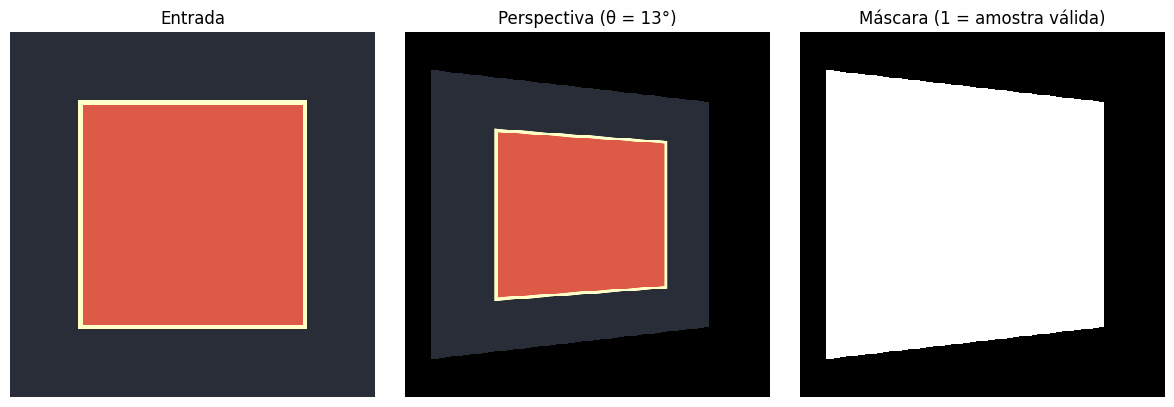

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(im)
ax[0].set_title("Entrada")
ax[1].imshow(virado)
ax[1].set_title(f"Perspectiva (θ = {ANGULO_GRAUS:.0f}°)")
ax[2].imshow(mascara, cmap="gray")
ax[2].set_title("Máscara (1 = amostra válida)")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()

A máscara em tons de cinza indica **onde** há correspondência válida entre o raio da câmera e o plano rotacionado. Fora dela não há textura para amostrar (pixels pretos na imagem perspética).

## 5. Sequência opcional: uma única “virada” (sem oscilar)

Em vez de um ciclo contínuo, geramos **poucos** quadros com o ângulo crescendo **linearmente** de \(0^\circ\) até `ANGULO_GRAUS` — só a transição de “de frente” para “de lado”. Se preferir só o resultado final, use apenas a seção 3.

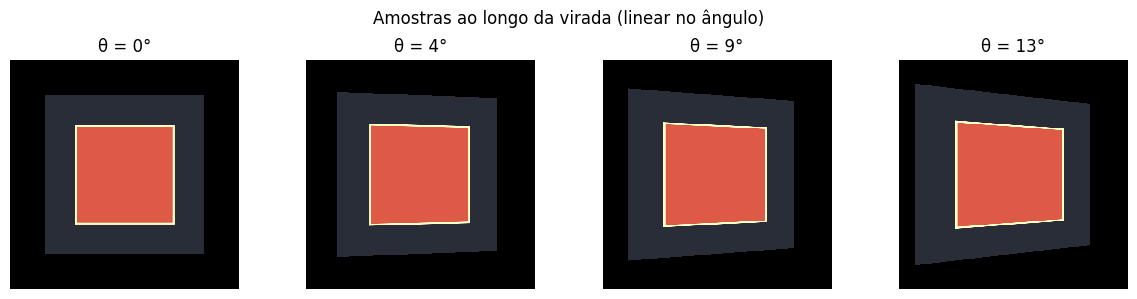

In [18]:
N_QUADROS = 16
thetas = np.deg2rad(np.linspace(0.0, ANGULO_GRAUS, N_QUADROS))
frames = np.stack([perspectiva_plano_rotacao_y(im, th)[0] for th in thetas], axis=0)

nc = min(4, N_QUADROS)
fig, axes = plt.subplots(1, nc, figsize=(3 * nc, 3))
for k, ax in enumerate(np.atleast_1d(axes).ravel()):
    idx = int(k * (N_QUADROS - 1) / max(nc - 1, 1))
    ax.imshow(frames[idx])
    ax.set_title(f"θ = {np.rad2deg(thetas[idx]):.0f}°")
    ax.axis("off")
plt.suptitle("Amostras ao longo da virada (linear no ângulo)")
plt.tight_layout()
plt.show()

## 6. Exportar GIF (opcional)

Salva a mesma sequência **monótona** (0° → ângulo final) em `quadrado_perspectiva.gif`. O GIF quantiza cores; para máxima fidelidade, use os arrays `frames` diretamente no notebook.

In [19]:
GIF_PATH = BASE / "quadrado_perspectiva.gif"
pil_frames = [
    Image.fromarray((np.clip(frames[i], 0, 1) * 255).astype(np.uint8))
    for i in range(N_QUADROS)
]
pil_frames[0].save(
    GIF_PATH,
    save_all=True,
    append_images=pil_frames[1:],
    duration=70,
    loop=0,
    optimize=False,
)
print("Salvo:", GIF_PATH.resolve())

Salvo: C:\Users\vinic\OneDrive\Documentos\ReposMackenzie\imagens-pseudo3D\quadrado_perspectiva.gif


## 7. Resumo

| Etapa | Papel |
|-------|--------|
| RGB de entrada | Textura no plano \(z=0\) |
| Rotação \(\mathrm{R}_y(\theta)\) | “Virar” o plano da figura para o lado |
| Interseção raio–plano + \(\mathrm{R}_y(-\theta)\) | Mapeamento inverso para \((s,t)\) na textura |
| `map_coordinates` (ordem 1) | Bilinear; cores só da entrada |

Para **paralaxe temporal** (estilo foto 3D ao mover o telefone), combinar este modelo com um **mapa de profundidade** por pixel; aqui a sensação de volume veio só da **perspectiva** de um plano único.